# ST-GCN on MediaPipe keypoints — ASL-only vs SGSL-only

Trains **two separate** spatio-temporal graph models on the **same layout** as `04_train_lstm_asl_sgsl_keypoints.ipynb`, using outputs from **`03_mediapipe_pose_hands_videos.ipynb`**.

| Experiment | Training data | Classes |
|------------|----------------|---------|
| **ASL only** | `Videos/ASL_60_pose_hands_keypoints` (or `ASL_pose_hands_keypoints`) | ASL gloss folder names |
| **SGSL only** | `Videos/SGSL_pose_hands_keypoints` | SGSL place folders |

Each frame is **`frame_XXXXXX.npy`** with shape **`(75, 5)`** (see `03_*`: columns **x, y, z, visibility, presence**). **Rows 0–32** are **BlazePose** (33 slots; face **0–10** are usually **NaN** in our export). **Rows 33–53** = **left hand** (21 MediaPipe hand landmarks). **Rows 54–74** = **right hand** (21).

The model ingests tensors **`(batch, time=SEQ_LEN, nodes=75, channels=C)`** where **`C` is 3** when z is present (xyz each multiplied by **visibility** clamped to \([0,1]\)), or **2** if the files only store **x, y** (first two columns).

**Graph (75 nodes, undirected):** edges are built in code from (1) **pose** links copied from MediaPipe **POSE_LANDMARKS** but **dropping any edge touching face indices 0–10** (matches the body-only overlay in `03_*`), (2) **standard MediaPipe hand topology** on each hand block, with global indices shifted by **+33** / **+54**, and (3) **bridges** **(pose left wrist 15 → hand node 33)** and **(pose right wrist 16 → hand node 54)**. The normalized adjacency includes a **self-loop** on every node (then symmetric \(D^{-1/2} A D^{-1/2}\)).

**Splits / metrics:** stratified **80 / 10 / 10** with the same **try/except fallback** as `04_*`. The **evaluation** cell matches **`04_*`**: confusion matrices on **train**, **val**, and **test**, with CSV exports and row-normalized plots.

**PyTorch:** install **once** in the same environment as Jupyter (CPU wheels are fine), then restart the kernel:

```bash
pip install "torch" "matplotlib" "scikit-learn>=1.3" "numpy>=1.26,<2"
```

Do **not** mix a heavy `%pip install torch` inside a TensorFlow-heavy session if that destabilizes your kernel — use a **separate venv** or install from Terminal, then open this notebook.

For a short run, export **`SIGNLANG_QUICK_RUN=1`** before starting Jupyter (caps epochs). **CPU-friendly:** small batch size, few DataLoader workers.


In [18]:
%pip install "torch" "matplotlib" "scikit-learn>=1.3" "numpy>=1.26,<2"



[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Optional: dependency check only
The next code cell verifies imports. If anything is missing, install from the **Terminal** (same Python as Jupyter), then **restart the kernel**.


In [19]:
import importlib.util
import sys

def _missing(pkgs: list[tuple[str, str]]) -> list[str]:
    lines = []
    for mod_name, pip_line in pkgs:
        if importlib.util.find_spec(mod_name) is None:
            lines.append(f"  - {pip_line}")
    return lines

_hints = _missing(
    [
        ("numpy", 'pip install "numpy>=1.26,<2"'),
        ("sklearn", 'pip install "scikit-learn>=1.3"'),
        ("torch", 'pip install torch'),
        ("matplotlib", 'pip install matplotlib'),
    ]
)
if _hints:
    print(
        "Missing dependencies. Install in Terminal (same Python as Jupyter), then restart the kernel:\n"
        + "\n".join(_hints),
        file=sys.stderr,
    )
    raise ImportError("Install dependencies (see messages above), restart Jupyter, then re-run.")

print("Dependencies OK.")

Dependencies OK.


In [20]:
from __future__ import annotations

import gc
import math
import os
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


def configure_threads() -> None:
    nt = os.environ.get("SIGNLANG_INTEROP_THREADS", "4")
    try:
        n = max(1, int(nt))
        torch.set_num_threads(n)
        torch.set_num_interop_threads(max(1, n // 2))
    except RuntimeError:
        pass
    except Exception:
        torch.set_num_threads(4)


configure_threads()

DEVICE = torch.device("cpu")


PROJECT_ROOT = Path(".").resolve()
_used_asl_60 = (PROJECT_ROOT / "Videos" / "ASL_60").is_dir()
ASL_KP_ROOT = (
    PROJECT_ROOT / "Videos" / "ASL_60_pose_hands_keypoints"
    if _used_asl_60
    else PROJECT_ROOT / "Videos" / "ASL_pose_hands_keypoints"
)
SGSL_KP_ROOT = PROJECT_ROOT / "Videos" / "SGSL_pose_hands_keypoints"

SEQ_LEN = 60
N_NODES = 75
RANDOM_STATE = 42
ARTIFACTS = PROJECT_ROOT / "artifacts_stgcn_asl_sgsl"
ARTIFACTS.mkdir(parents=True, exist_ok=True)

_QUICK = os.environ.get("SIGNLANG_QUICK_RUN", "").lower() in ("1", "true", "yes")
MAX_EPOCHS = 40 if _QUICK else 500
BATCH_SIZE = 8
TRAIN_NUM_WORKERS = 0
LR = 1e-3
EARLY_PATIENCE = 15
LR_PLATEAU_PATIENCE = 8
LR_PLATEAU_FACTOR = 0.5
LR_MIN = 1e-5
DROPOUT = 0.3

# ---- Graph edges ( MediaPipe BlazePose + hands ) ----
# Full POSE_LANDMARKS pairs (legacy index order), then drop anything touching face 0..10.
_POSE_FACE = frozenset(range(11))
_POSE_ALL_EDGES = [
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 7),
    (0, 4),
    (4, 5),
    (5, 6),
    (6, 8),
    (9, 10),
    (11, 12),
    (11, 13),
    (13, 15),
    (15, 17),
    (15, 19),
    (15, 21),
    (17, 19),
    (12, 14),
    (14, 16),
    (16, 18),
    (16, 20),
    (16, 22),
    (18, 20),
    (11, 23),
    (12, 24),
    (23, 24),
    (23, 25),
    (24, 26),
    (25, 27),
    (26, 28),
    (27, 29),
    (28, 30),
    (29, 31),
    (30, 32),
    (27, 31),
    (28, 32),
]
_POSE_BODY_EDGES = [
    (i, j)
    for i, j in _POSE_ALL_EDGES
    if i not in _POSE_FACE and j not in _POSE_FACE
]

# MediaPipe HAND_CONNECTIONS in local landmark indices (0=wrist …).
_HAND_LOCAL_EDGES = [
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 4),
    (0, 5),
    (5, 6),
    (6, 7),
    (7, 8),
    (0, 9),
    (9, 10),
    (10, 11),
    (11, 12),
    (0, 13),
    (13, 14),
    (14, 15),
    (15, 16),
    (0, 17),
    (17, 18),
    (18, 19),
    (19, 20),
]

_N_POSE = 33
_N_HAND = 21
_OFF_L = _N_POSE
_OFF_R = _N_POSE + _N_HAND

def build_adjacency_matrix(v: int = N_NODES) -> np.ndarray:
    """Binary symmetric adjacency including self-loops later in normalization."""
    A = np.zeros((v, v), dtype=np.float32)
    for i, j in _POSE_BODY_EDGES:
        if 0 <= i < v and 0 <= j < v:
            A[i, j] = 1.0
            A[j, i] = 1.0
    for off in (_OFF_L, _OFF_R):
        for a, b in _HAND_LOCAL_EDGES:
            i, j = off + a, off + b
            A[i, j] = 1.0
            A[j, i] = 1.0
    # Wrist roots: pose wrists (15,16) connect to hand wrist landmarks (offset+0).
    A[15, _OFF_L] = 1.0
    A[_OFF_L, 15] = 1.0
    A[16, _OFF_R] = 1.0
    A[_OFF_R, 16] = 1.0
    return A


def normalized_adjacency_torch(A: np.ndarray) -> torch.Tensor:
    """Symmetric normalized adjacency with self-loop: D^{-1/2}(A+I)D^{-1/2}."""
    adj = torch.as_tensor(A, dtype=torch.float32)
    i = torch.eye(adj.size(0), dtype=adj.dtype)
    a = adj + i
    d = a.sum(dim=1).clamp(min=1e-6)
    d_inv_sqrt = d.pow(-0.5)
    return (d_inv_sqrt[:, None] * a) * d_inv_sqrt[None, :]


A_np = build_adjacency_matrix()
A_HAT = normalized_adjacency_torch(A_np).to(DEVICE)


def _sorted_clip_dirs(class_dir: Path) -> list[Path]:
    out = []
    for p in class_dir.iterdir():
        if not p.is_dir() or p.name.startswith("."):
            continue
        try:
            out.append((int(p.name), p))
        except ValueError:
            out.append((p.name, p))
    out.sort(key=lambda t: t[0])
    return [p for _, p in out]


def _channels_from_frame(frame: np.ndarray) -> tuple[np.ndarray, int]:
    """Return (V, C) float32 node features and C (2 or 3)."""
    frame = np.nan_to_num(frame.astype(np.float32), nan=0.0, posinf=0.0, neginf=0.0)
    if frame.ndim != 2:
        raise ValueError("expected 2D frame")
    nrows, nf = frame.shape
    if nf >= 5:
        xyz = frame[:, :3]
        vis = np.clip(frame[:, 3:4], 0.0, 1.0)
        feat = xyz * vis
        return feat, 3
    if nf >= 3:
        return frame[:, :3].copy(), 3
    if nf == 2:
        return frame[:, :2].copy(), 2
    raise ValueError(f"unexpected feature width {nf}")


def load_graph_clip(clip_dir: Path, seq_len: int) -> np.ndarray | None:
    """Return float32 (seq_len, 75, C) or None."""
    files = sorted(clip_dir.glob("frame_*.npy"))
    if not files:
        return None
    frames: list[np.ndarray] = []
    c_ref: int | None = None
    for f in files[:seq_len]:
        a = np.load(f)
        fe, c = _channels_from_frame(a)
        if fe.shape[0] != N_NODES:
            return None
        if c_ref is None:
            c_ref = c
        elif c != c_ref:
            return None
        frames.append(fe.astype(np.float32, copy=False))
    if c_ref is None:
        return None
    if len(frames) < seq_len:
        pad = np.zeros((seq_len - len(frames), N_NODES, c_ref), dtype=np.float32)
        frames.extend(list(pad))
    return np.stack(frames[:seq_len], axis=0).astype(np.float32)


def collect_from_root(key_root: Path, label_fn) -> tuple[list[np.ndarray], list[str]]:
    X_list: list[np.ndarray] = []
    y_list: list[str] = []
    if not key_root.is_dir():
        return X_list, y_list
    class_dirs = sorted(
        [p for p in key_root.iterdir() if p.is_dir() and not p.name.startswith(".")],
        key=lambda p: p.name.lower(),
    )
    for cdir in class_dirs:
        lbl = label_fn(cdir.name)
        for clip in _sorted_clip_dirs(cdir):
            seq = load_graph_clip(clip, SEQ_LEN)
            if seq is None:
                continue
            if not np.isfinite(seq).all():
                continue
            X_list.append(seq)
            y_list.append(lbl)
    return X_list, y_list


def stack_labels(X_list: list[np.ndarray], y_labels: list[str]) -> tuple[np.ndarray, np.ndarray, LabelEncoder, int]:
    if not X_list:
        raise ValueError("No sequences loaded — run `03_*` keypoint export first.")
    X = np.stack(X_list, axis=0).astype(np.float32)
    le = LabelEncoder()
    y_int = le.fit_transform(y_labels).astype(np.int64)
    c_in = int(X.shape[-1])
    return X, y_int, le, c_in


def _train_test_maybe_stratify(*arrays, test_size: float, stratify=None):
    kwargs = {"test_size": test_size, "random_state": RANDOM_STATE}
    try:
        return train_test_split(*arrays, stratify=stratify, **kwargs)
    except ValueError:
        return train_test_split(*arrays, **kwargs)


def stratified_three_way(X, y_int):
    X_train, X_tmp, y_train, y_tmp = _train_test_maybe_stratify(
        X, y_int, test_size=0.20, stratify=y_int
    )
    X_val, X_test, y_val, y_test = _train_test_maybe_stratify(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp
    )
    return (X_train, y_train), (X_val, y_val), (X_test, y_test)


def class_weights_from_y(y_train: np.ndarray, num_classes: int) -> torch.Tensor:
    counts = np.bincount(y_train, minlength=num_classes).astype(np.float64)
    inv = (counts.sum() / (counts + 1e-12)) / num_classes
    w = inv[y_train].astype(np.float32)
    return torch.as_tensor(w, dtype=torch.float32)


class STBlock(nn.Module):
    def __init__(
        self,
        in_c: int,
        out_c: int,
        a_hat: torch.Tensor,
        temporal_k: int = 9,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.register_buffer("a_hat", a_hat)
        self.drop = dropout
        self.spatial = nn.Conv2d(in_c, out_c, kernel_size=1)
        self.bn_s = nn.BatchNorm2d(out_c)
        pad = temporal_k // 2
        self.temporal = nn.Conv2d(out_c, out_c, kernel_size=(temporal_k, 1), padding=(pad, 0))
        self.bn_t = nn.BatchNorm2d(out_c)
        self.proj = nn.Conv2d(in_c, out_c, kernel_size=1) if in_c != out_c else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: N, C, T, V
        xg = torch.einsum("vu,nctu->nctv", self.a_hat, x)
        y = self.spatial(xg)
        y = self.bn_s(y)
        y = F.relu(y)
        y = self.temporal(y)
        y = self.bn_t(y)
        y = F.relu(y)
        if self.drop and self.drop > 0:
            y = F.dropout(y, p=self.drop, training=self.training)
        r = self.proj(x)
        return F.relu(y + r)


class STGCNClassifier(nn.Module):
    def __init__(self, in_ch: int, num_classes: int, a_hat: torch.Tensor):
        super().__init__()
        self.b1 = STBlock(in_ch, 64, a_hat, dropout=DROPOUT)
        self.b2 = STBlock(64, 128, a_hat, dropout=DROPOUT)
        self.b3 = STBlock(128, 128, a_hat, dropout=DROPOUT)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: N, C, T, V
        x = self.b1(x)
        x = self.b2(x)
        x = self.b3(x)
        x = self.pool(x)
        x = x.flatten(1)
        return self.fc(x)


@torch.no_grad()
def predict_logits(model: nn.Module, X: np.ndarray, batch: int) -> np.ndarray:
    model.eval()
    outs: list[np.ndarray] = []
    n = len(X)
    for i in range(0, n, batch):
        chunk = torch.as_tensor(X[i : i + batch], device=DEVICE)
        chunk = chunk.permute(0, 3, 1, 2).contiguous()
        outs.append(model(chunk).cpu().numpy())
    return np.concatenate(outs, axis=0)


def train_one_run(
    name: str,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    yi_test: np.ndarray,
) -> dict:
    num_classes = int(y_train.max()) + 1
    c_in = int(X_train.shape[-1])

    sw = class_weights_from_y(y_train, num_classes)

    train_ds = torch.utils.data.TensorDataset(
        torch.as_tensor(X_train),
        torch.as_tensor(y_train),
        sw,
    )
    train_loader = torch.utils.data.DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=TRAIN_NUM_WORKERS,
        drop_last=False,
    )

    X_val_t = torch.as_tensor(X_val, device=DEVICE)
    y_val_t = torch.as_tensor(y_val, device=DEVICE)

    model = STGCNClassifier(c_in, num_classes, A_HAT).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode="min",
        factor=LR_PLATEAU_FACTOR,
        patience=LR_PLATEAU_PATIENCE,
        min_lr=LR_MIN,
    )
    crit = nn.CrossEntropyLoss(reduction="none")

    ckpt_path = ARTIFACTS / f"stgcn_{name}_best.pt"
    best_val = math.inf
    best_state = None
    stall = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        running = 0.0
        n_seen = 0
        for xb, yb, wb in train_loader:
            xb = xb.to(DEVICE).float()
            yb = yb.to(DEVICE)
            wb = wb.to(DEVICE)
            xbc = xb.permute(0, 3, 1, 2).contiguous()
            opt.zero_grad(set_to_none=True)
            logits = model(xbc)
            loss_elems = crit(logits, yb)
            loss = (loss_elems * wb).sum() / (wb.sum().clamp(min=1e-6))
            loss.backward()
            opt.step()
            running += float(loss.item()) * len(xb)
            n_seen += len(xb)
        train_loss = running / max(1, n_seen)

        model.eval()
        with torch.no_grad():
            xv = X_val_t.float().permute(0, 3, 1, 2)
            logits_v = model(xv)
            val_loss = float(F.cross_entropy(logits_v, y_val_t).item())

        sched.step(val_loss)

        improved = val_loss < best_val - 1e-6
        if improved:
            best_val = val_loss
            stall = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            torch.save(
                {"model": best_state, "in_ch": c_in, "num_classes": num_classes, "name": name},
                ckpt_path,
            )
        else:
            stall += 1

        if epoch % 10 == 0 or epoch == 1:
            lr = opt.param_groups[0]["lr"]
            print(
                f"Epoch {epoch}/{MAX_EPOCHS} "
                f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} lr={lr:.6f}"
            )

        if stall >= EARLY_PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    else:
        print("[warn] No improvement — using last epoch weights.")

    logits_te = predict_logits(model, X_test, BATCH_SIZE)
    pred = np.argmax(logits_te, axis=1)

    del logits_te
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    out = {
        "name": name,
        "test_accuracy": float(accuracy_score(yi_test, pred)),
        "n_classes": int(num_classes),
        "n_test": int(len(X_test)),
        "checkpoint": str(ckpt_path),
        "channels_in": int(c_in),
    }

    print("\n===", name, "===")
    for k in sorted(out.keys()):
        if k != "name":
            print(f"  {k}: {out[k]}")

    return out

In [21]:
results: list[dict] = []

# ----- ASL only -----
print("ASL keypoints root:", ASL_KP_ROOT)
X_a, y_a = collect_from_root(ASL_KP_ROOT, lambda g: g)
if len(X_a) == 0:
    print("[SKIP] No ASL keypoint sequences — export keypoints with `03_*`.")
else:
    X, y_int, le_asl, _c = stack_labels(X_a, y_a)
    (tr, va, te) = stratified_three_way(X, y_int)
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = tr, va, te
    results.append(
        train_one_run(
            "ASL_only",
            X_train,
            y_train,
            X_val,
            y_val,
            X_test,
            y_test,
            y_test,
        )
    )
    del X, X_train, X_val, X_test, y_train, y_val, y_test
    gc.collect()

# ----- SGSL only -----
print("SGSL keypoints root:", SGSL_KP_ROOT)
X_s, y_s = collect_from_root(SGSL_KP_ROOT, lambda p: p)
if len(X_s) == 0:
    print("[SKIP] No SGSL keypoint sequences.")
else:
    X, y_int, le_sgsl, _c = stack_labels(X_s, y_s)
    (tr, va, te) = stratified_three_way(X, y_int)
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = tr, va, te
    results.append(
        train_one_run(
            "SGSL_only",
            X_train,
            y_train,
            X_val,
            y_val,
            X_test,
            y_test,
            y_test,
        )
    )
    del X, X_train, X_val, X_test, y_train, y_val, y_test
    gc.collect()


ASL keypoints root: /Users/sritampatnaik/Masters/NUS-ISS Sritam/NUS-ISS Sem 3/Sign-Lang/Videos/ASL_60_pose_hands_keypoints
Epoch 1/500 train_loss=1.6937 val_loss=1.8060 lr=0.001000
Epoch 10/500 train_loss=1.0734 val_loss=1.0169 lr=0.001000
Epoch 20/500 train_loss=0.9276 val_loss=0.8405 lr=0.001000
Epoch 30/500 train_loss=0.6585 val_loss=0.6905 lr=0.000500
Epoch 40/500 train_loss=0.6404 val_loss=0.8219 lr=0.000500
Epoch 50/500 train_loss=0.4220 val_loss=0.3826 lr=0.000250
Epoch 60/500 train_loss=0.3553 val_loss=0.7254 lr=0.000250
Epoch 70/500 train_loss=0.3984 val_loss=0.4159 lr=0.000250
Epoch 80/500 train_loss=0.2659 val_loss=0.4179 lr=0.000250
Epoch 90/500 train_loss=0.2391 val_loss=0.3628 lr=0.000125
Epoch 100/500 train_loss=0.2243 val_loss=0.4196 lr=0.000063
Early stopping at epoch 102

=== ASL_only ===
  channels_in: 3
  checkpoint: /Users/sritampatnaik/Masters/NUS-ISS Sritam/NUS-ISS Sem 3/Sign-Lang/artifacts_stgcn_asl_sgsl/stgcn_ASL_only_best.pt
  n_classes: 6
  n_test: 18
  test_

In [22]:
# Summary (no pandas dependency)
if not results:
    print("No experiments ran.")
else:
    keys = sorted({k for r in results for k in r})
    header = " | ".join(keys)
    print(header)
    print("-" * len(header))
    for r in results:
        print(" | ".join(str(r.get(k, "")) for k in keys))

channels_in | checkpoint | n_classes | n_test | name | test_accuracy
--------------------------------------------------------------------
3 | /Users/sritampatnaik/Masters/NUS-ISS Sritam/NUS-ISS Sem 3/Sign-Lang/artifacts_stgcn_asl_sgsl/stgcn_ASL_only_best.pt | 6 | 18 | ASL_only | 0.7222222222222222
3 | /Users/sritampatnaik/Masters/NUS-ISS Sritam/NUS-ISS Sem 3/Sign-Lang/artifacts_stgcn_asl_sgsl/stgcn_SGSL_only_best.pt | 6 | 18 | SGSL_only | 0.8333333333333334


### Evaluation — train / validation / test (aligned with `04_train_lstm_asl_sgsl_keypoints.ipynb`)

For each corpus, load **`artifacts_stgcn_asl_sgsl/stgcn_<run>_best.pt`**, rebuild the **same stratified 80/10/10 split** (`RANDOM_STATE`), then for **train**, **val**, and **test**:

- Accuracy and **`classification_report`**
- Raw and row-normalized confusion matrices as **`{run}_{split}_cm.csv`** / **`{run}_{split}_cm_norm.csv`**
- Normalized confusion plot **`{run}_{split}_cm.png`**

Run **after** training so checkpoints exist.



=== ASL_ONLY · TRAIN ===
Accuracy: 0.9375
              precision    recall  f1-score   support

      africa     1.0000    0.8750    0.9333        24
   australia     1.0000    1.0000    1.0000        24
        city     1.0000    0.8333    0.9091        24
     college     1.0000    0.9167    0.9565        24
      school     0.8000    1.0000    0.8889        24
       south     0.8889    1.0000    0.9412        24

    accuracy                         0.9375       144
   macro avg     0.9481    0.9375    0.9382       144
weighted avg     0.9481    0.9375    0.9382       144



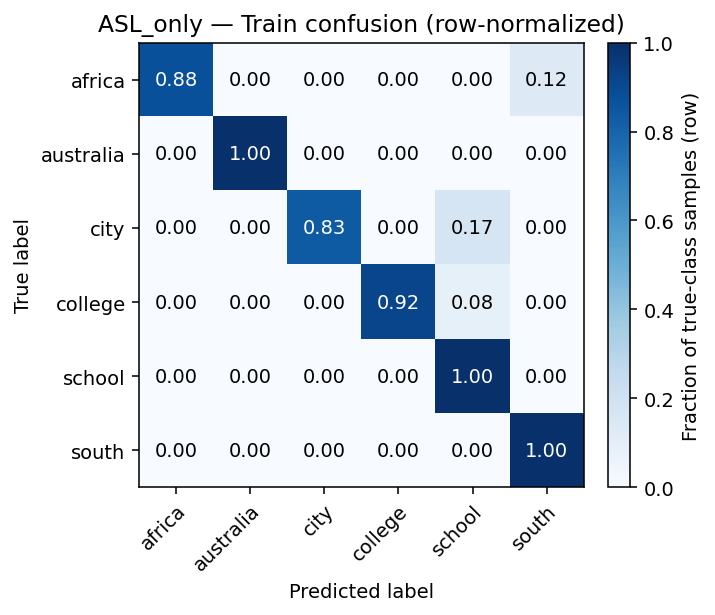


=== ASL_ONLY · VAL ===
Accuracy: 0.9444
              precision    recall  f1-score   support

      africa     1.0000    1.0000    1.0000         3
   australia     1.0000    1.0000    1.0000         3
        city     1.0000    1.0000    1.0000         3
     college     1.0000    0.6667    0.8000         3
      school     0.7500    1.0000    0.8571         3
       south     1.0000    1.0000    1.0000         3

    accuracy                         0.9444        18
   macro avg     0.9583    0.9444    0.9429        18
weighted avg     0.9583    0.9444    0.9429        18



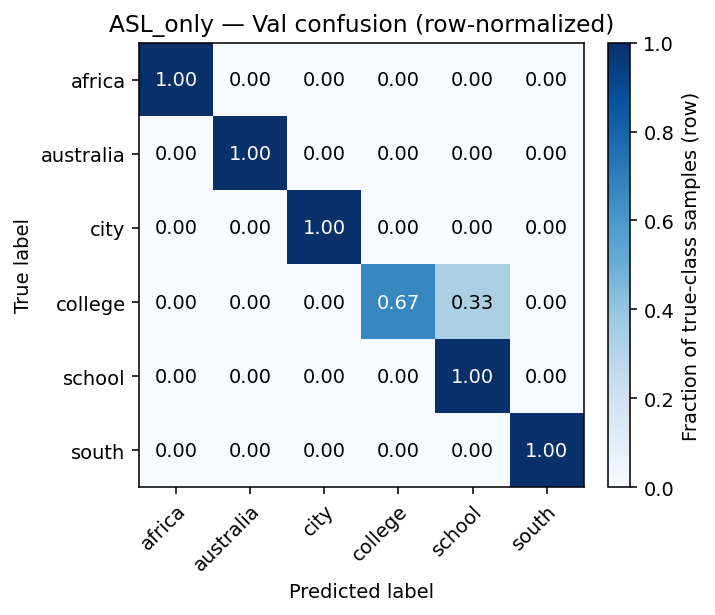


=== ASL_ONLY · TEST ===
Accuracy: 0.7222
              precision    recall  f1-score   support

      africa     1.0000    0.3333    0.5000         3
   australia     1.0000    1.0000    1.0000         3
        city     1.0000    0.3333    0.5000         3
     college     1.0000    0.6667    0.8000         3
      school     0.5000    1.0000    0.6667         3
       south     0.6000    1.0000    0.7500         3

    accuracy                         0.7222        18
   macro avg     0.8500    0.7222    0.7028        18
weighted avg     0.8500    0.7222    0.7028        18



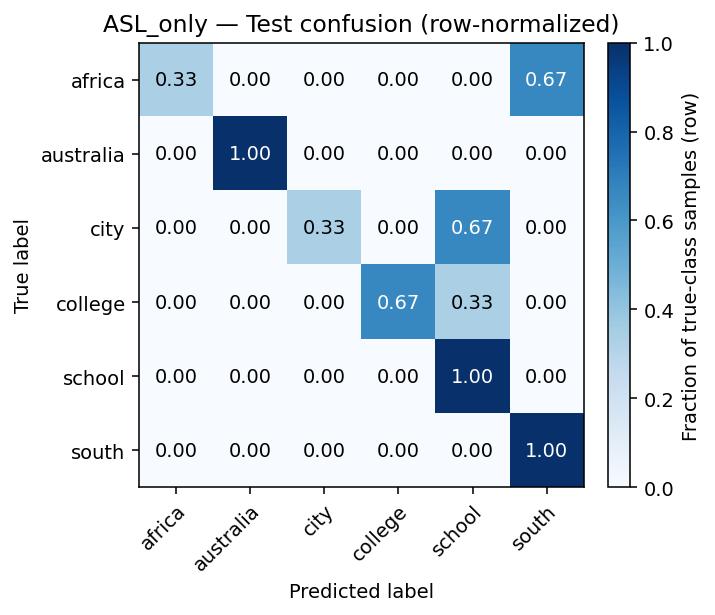


Saved CSV/PNG confusion matrices under: /Users/sritampatnaik/Masters/NUS-ISS Sritam/NUS-ISS Sem 3/Sign-Lang/artifacts_stgcn_asl_sgsl

=== SGSL_ONLY · TRAIN ===
Accuracy: 0.9444
              precision    recall  f1-score   support

       Bedok     0.9600    1.0000    0.9796        24
   City Hall     1.0000    1.0000    1.0000        24
    Clementi     0.7742    1.0000    0.8727        24
   Esplanade     1.0000    1.0000    1.0000        24
         MBS     1.0000    1.0000    1.0000        24
     Orchard     1.0000    0.6667    0.8000        24

    accuracy                         0.9444       144
   macro avg     0.9557    0.9444    0.9421       144
weighted avg     0.9557    0.9444    0.9421       144



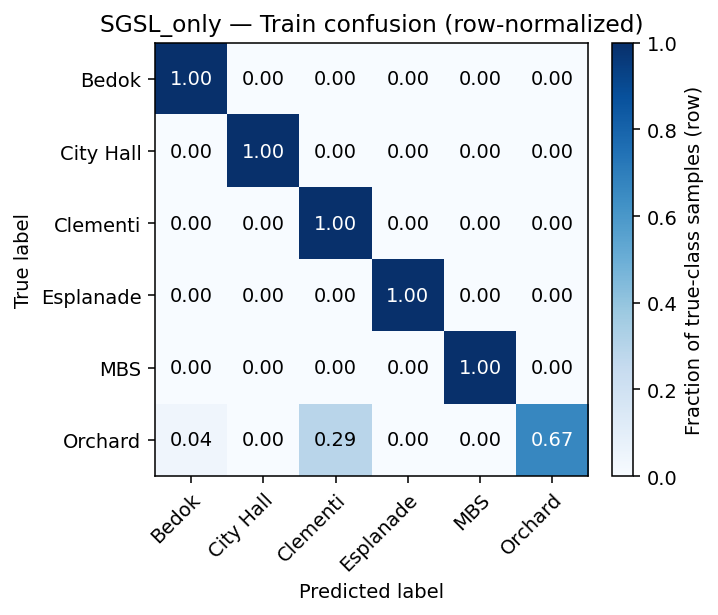


=== SGSL_ONLY · VAL ===
Accuracy: 0.9444
              precision    recall  f1-score   support

       Bedok     1.0000    0.6667    0.8000         3
   City Hall     1.0000    1.0000    1.0000         3
    Clementi     1.0000    1.0000    1.0000         3
   Esplanade     1.0000    1.0000    1.0000         3
         MBS     1.0000    1.0000    1.0000         3
     Orchard     0.7500    1.0000    0.8571         3

    accuracy                         0.9444        18
   macro avg     0.9583    0.9444    0.9429        18
weighted avg     0.9583    0.9444    0.9429        18



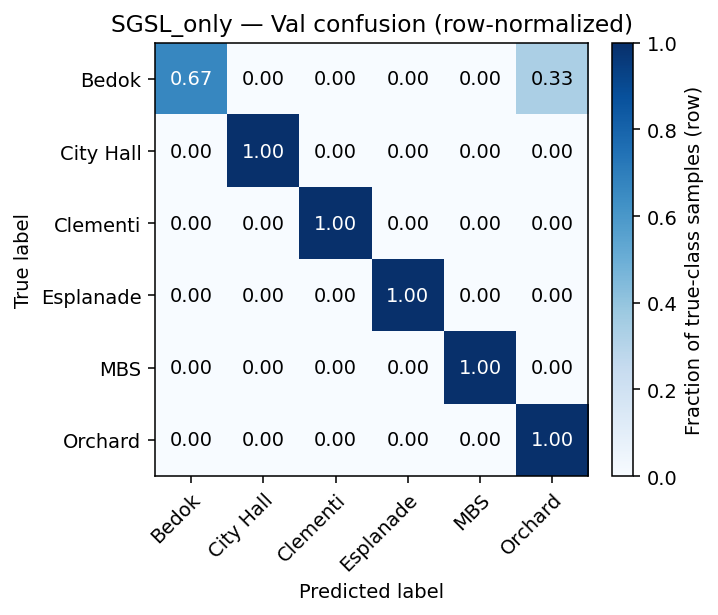


=== SGSL_ONLY · TEST ===
Accuracy: 0.8333
              precision    recall  f1-score   support

       Bedok     1.0000    0.6667    0.8000         3
   City Hall     1.0000    1.0000    1.0000         3
    Clementi     0.6667    0.6667    0.6667         3
   Esplanade     1.0000    1.0000    1.0000         3
         MBS     1.0000    1.0000    1.0000         3
     Orchard     0.5000    0.6667    0.5714         3

    accuracy                         0.8333        18
   macro avg     0.8611    0.8333    0.8397        18
weighted avg     0.8611    0.8333    0.8397        18



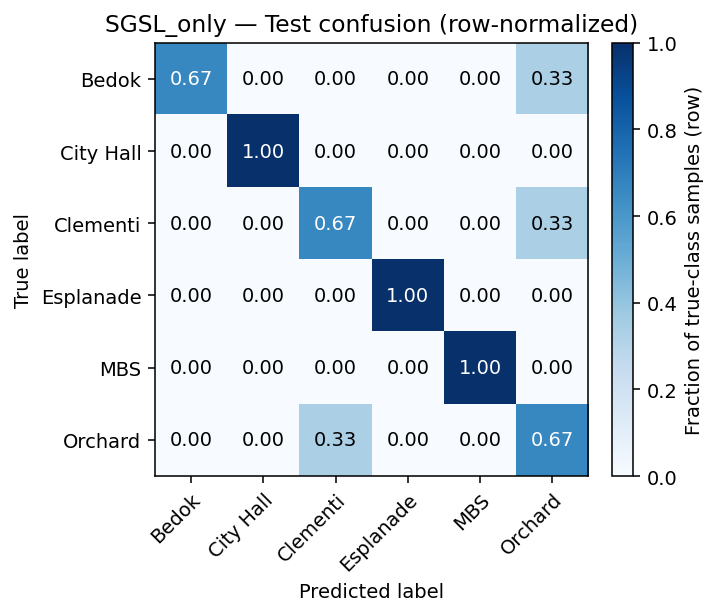


Saved CSV/PNG confusion matrices under: /Users/sritampatnaik/Masters/NUS-ISS Sritam/NUS-ISS Sem 3/Sign-Lang/artifacts_stgcn_asl_sgsl


In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


def load_best_stgcn(name: str) -> torch.nn.Module:
    ckpt_path = ARTIFACTS / f"stgcn_{name}_best.pt"
    if not ckpt_path.is_file():
        raise FileNotFoundError(f"Missing checkpoint: {ckpt_path}")
    try:
        ck = torch.load(str(ckpt_path), map_location=DEVICE, weights_only=False)
    except TypeError:
        ck = torch.load(str(ckpt_path), map_location=DEVICE)
    model = STGCNClassifier(int(ck["in_ch"]), int(ck["num_classes"]), A_HAT).to(DEVICE)
    model.load_state_dict(ck["model"])
    model.eval()
    return model


def evaluate_split_stgcn(
    model: torch.nn.Module,
    X: np.ndarray,
    y_int: np.ndarray,
    *,
    split_name: str,
    corpus_tag: str,
    class_names: list[str],
) -> tuple[float, np.ndarray, np.ndarray]:
    """Mirror `04_train_lstm_*` evaluation: metrics, CSVs, row-normalized CM PNG."""
    num_classes = len(class_names)
    logits = predict_logits(model, X, BATCH_SIZE)
    y_pred = logits.argmax(axis=1)
    y_true = np.asarray(y_int)
    del logits

    acc = float(accuracy_score(y_true, y_pred))
    print(f"\n=== {corpus_tag.upper()} · {split_name.upper()} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    labels = np.arange(num_classes)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    with np.errstate(invalid="ignore", divide="ignore"):
        cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True).clip(min=1)

    stem = f"{corpus_tag}_{split_name}"
    np.savetxt(ARTIFACTS / f"{stem}_cm.csv", cm, fmt="%d", delimiter=",")
    np.savetxt(ARTIFACTS / f"{stem}_cm_norm.csv", cm_norm, fmt="%.6f", delimiter=",")

    fig, ax = plt.subplots(figsize=(5.5, 4.5), dpi=140)
    im = ax.imshow(
        cm_norm,
        interpolation="nearest",
        cmap="Blues",
        vmin=0.0,
        vmax=1.0,
        aspect="equal",
    )
    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cbar.set_label("Fraction of true-class samples (row)")
    ax.set(
        xticks=np.arange(num_classes),
        yticks=np.arange(num_classes),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel="True label",
        xlabel="Predicted label",
        title=f"{corpus_tag} — {split_name.title()} confusion (row-normalized)",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    text_thresh = 0.55
    for i in range(num_classes):
        for j in range(num_classes):
            val = cm_norm[i, j] if np.isfinite(cm_norm[i, j]) else 0.0
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                color="white" if val > text_thresh else "black",
            )
    fig.tight_layout()
    fig.savefig(ARTIFACTS / f"{stem}_cm.png", bbox_inches="tight")
    plt.show()

    return acc, cm, cm_norm


def evaluate_stgcn_corpus_three_way(name: str, key_root: Path, label_fn) -> None:
    ckpt = ARTIFACTS / f"stgcn_{name}_best.pt"
    if not ckpt.is_file():
        print(f"[SKIP] {name}: no checkpoint at {ckpt}")
        return

    X_list, y_labels = collect_from_root(key_root, label_fn)
    if not X_list:
        print(f"[SKIP] {name}: no sequences under {key_root}")
        return

    X, y_int, le, _c = stack_labels(X_list, y_labels)
    (tr, va, te) = stratified_three_way(X, y_int)
    (X_train, y_train), (X_val, y_val), (X_test, y_test) = tr, va, te

    model = load_best_stgcn(name)
    class_names = [str(c) for c in le.classes_]

    evaluate_split_stgcn(model, X_train, y_train, split_name="train", corpus_tag=name, class_names=class_names)
    evaluate_split_stgcn(model, X_val, y_val, split_name="val", corpus_tag=name, class_names=class_names)
    evaluate_split_stgcn(model, X_test, y_test, split_name="test", corpus_tag=name, class_names=class_names)

    del model
    gc.collect()
    print("\nSaved CSV/PNG confusion matrices under:", ARTIFACTS.resolve())


evaluate_stgcn_corpus_three_way("ASL_only", ASL_KP_ROOT, lambda g: g)
evaluate_stgcn_corpus_three_way("SGSL_only", SGSL_KP_ROOT, lambda p: p)
